# State of Data Brasil — Análise de Gênero (2021–2024)

> **Objetivo:** Investigar desigualdades de gênero no mercado de dados brasileiro a partir das edições 2021, 2022, 2023 e 2024 do State of Data Brasil.  
> **Recorte temático:** Gênero × Remuneração, Faixa Salarial e Senioridade.  
> **Estrutura:**
>
> | Seção | Conteúdo |
> |-------|----------|
> | 0 | Configurações, mapeamentos e constantes |
> | 1 | Carregamento e pipeline de pré-processamento |
> | 2 | Análise Exploratória — perfil por gênero |
> | 3 | Análise Exploratória — recorte regional |
> | 4 | Análise Estatística inferencial |
> | 5 | Modelagem preditiva (ML) |
> | 6 | Explicabilidade com SHAP |

---


---
## Seção 0 — Configurações, Mapeamentos e Constantes

Esta seção centraliza **todos** os mapeamentos e constantes do projeto.  
Qualquer ajuste de nomenclatura, categoria ou cor deve ser feito aqui — o restante do notebook lê essas variáveis.


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import os

# Visualização
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

# Estatística
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu
import statsmodels.api as sm

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from xgboost import XGBClassifier
import shap

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

SEED = 42
np.random.seed(SEED)
ALPHA = 0.05  # nível de significância para todos os testes

print('✅ Imports OK')


✅ Imports OK


### 0.1 Mapeamento de colunas por ano

O State of Data mudou os nomes das colunas a cada edição.  
O dicionário abaixo mapeia cada coluna para um nome padronizado, permitindo concatenar os 4 anos sem conflito.


In [2]:
# ---------------------------------------------------------------------------
# Mapeamento de colunas originais → nomes padronizados, por ano
# ---------------------------------------------------------------------------
COLUMN_MAPPING = {
    '2021': {
        'idade':           "('P1_a ', 'Idade')",
        'faixa_idade':     "('P1_a_a ', 'Faixa idade')",
        'genero':          "('P1_b ', 'Genero')",
        'estado':          "('P1_e ', 'Estado onde mora')",
        'uf':              "('P1_e_a ', 'uf onde mora')",
        'regiao':          "('P1_e_b ', 'Regiao onde mora')",
        'regiao_origem':   "('P1_g_b ', 'Regiao de origem')",
        'nivel_ensino':    "('P1_h ', 'Nivel de Ensino')",
        'area_formacao':   "('P1_i ', 'Área de Formação')",
        'situacao':        "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':           "('P2_b ', 'Setor')",
        'cargo':           "('P2_f ', 'Cargo Atual')",
        'gestor':          "('P2_d ', 'Gestor?')",
        'nivel':           "('P2_g ', 'Nivel')",
        'faixa_salarial':  "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados':"('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':   "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':      "('P2_q ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2022': {
        'idade':           "('P1_a ', 'Idade')",
        'faixa_idade':     "('P1_a_1 ', 'Faixa idade')",
        'genero':          "('P1_b ', 'Genero')",
        'estado':          "('P1_i ', 'Estado onde mora')",
        'uf':              "('P1_i_1 ', 'uf onde mora')",
        'regiao':          "('P1_i_2 ', 'Regiao onde mora')",
        'regiao_origem':   "('P1_k ', 'Regiao de origem')",
        'nivel_ensino':    "('P1_l ', 'Nivel de Ensino')",
        'area_formacao':   "('P1_m ', 'Área de Formação')",
        'situacao':        "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':           "('P2_b ', 'Setor')",
        'cargo':           "('P2_f ', 'Cargo Atual')",
        'gestor':          "('P2_d ', 'Gestor?')",
        'nivel':           "('P2_g ', 'Nivel')",
        'faixa_salarial':  "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados':"('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':   "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':      "('P2_p ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2023': {
        'idade':           "('P1_a ', 'Idade')",
        'faixa_idade':     "('P1_a_1 ', 'Faixa idade')",
        'genero':          "('P1_b ', 'Genero')",
        'estado':          "('P1_i ', 'Estado onde mora')",
        'uf':              "('P1_i_1 ', 'uf onde mora')",
        'regiao':          "('P1_i_2 ', 'Regiao onde mora')",
        'regiao_origem':   "('P1_k ', 'Regiao de origem')",
        'nivel_ensino':    "('P1_l ', 'Nivel de Ensino')",
        'area_formacao':   "('P1_m ', 'Área de Formação')",
        'situacao':        "('P2_a ', 'Qual sua situação atual de trabalho?')",
        'setor':           "('P2_b ', 'Setor')",
        'cargo':           "('P2_f ', 'Cargo Atual')",
        'gestor':          "('P2_d ', 'Gestor?')",
        'nivel':           "('P2_g ', 'Nivel')",
        'faixa_salarial':  "('P2_h ', 'Faixa salarial')",
        'tempo_area_dados':"('P2_i ', 'Quanto tempo de experiência na área de dados você tem?')",
        'tempo_area_ti':   "('P2_j ', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?')",
        'modalidade':      "('P2_r ', 'Atualmente qual a sua forma de trabalho?')",
    },
    '2024': {
        'idade':           '1.a_idade',
        'faixa_idade':     '1.a.1_faixa_idade',
        'genero':          '1.b_genero',
        'estado':          '1.i_estado_onde_mora',
        'uf':              '1.i.1_uf_onde_mora',
        'regiao':          '1.i.2_regiao_onde_mora',
        'regiao_origem':   '1.k.2_regiao_de_origem',
        'nivel_ensino':    '1.l_nivel_de_ensino',
        'area_formacao':   '1.m_área_de_formação',
        'situacao':        '2.a_situação_de_trabalho',
        'setor':           '2.b_setor',
        'cargo':           '2.f_cargo_atual',
        'gestor':          '2.d_atua_como_gestor',
        'nivel':           '2.g_nivel',
        'faixa_salarial':  '2.h_faixa_salarial',
        'tempo_area_dados':'2.i_tempo_de_experiencia_em_dados',
        'tempo_area_ti':   '2.j_tempo_de_experiencia_em_ti',
        'modalidade':      '2.r_modelo_de_trabalho_atual',
    }
}
print('✅ COLUMN_MAPPING definido')


✅ COLUMN_MAPPING definido


### 0.2 Colunas de IA Generativa (exclusivas de 2024)

O survey de 2024 adicionou um bloco de perguntas sobre adoção de IA generativa.  
Essas colunas **não existem** em 2021–2023 e serão preenchidas com `NaN` para esses anos.


In [3]:
# Colunas de IA generativa — exclusivas do dataset 2024
IA_COLS = {
    # 3.f: Tipo de uso na empresa (perspectiva do gestor)
    'ia_gest_independente':   '3.f.1',
    'ia_gest_centralizado':   '3.f.2',
    'ia_gest_copilot_devs':   '3.f.3',
    'ia_gest_prod_externo':   '3.f.4',
    'ia_gest_prod_interno':   '3.f.5',
    'ia_gest_frente_negocio': '3.f.6',
    'ia_gest_nao_prioridade': '3.f.7',
    'ia_gest_nao_sei':        '3.f.8',
    # 3.g: Barreiras para não usar IA (perspectiva do gestor)
    'ia_bar_casos_uso':       '3.g.1',
    'ia_bar_alucinacao':      '3.g.2',
    'ia_bar_regulacao':       '3.g.3',
    'ia_bar_privacidade':     '3.g.4',
    'ia_bar_roi':             '3.g.5',
    'ia_bar_dados':           '3.g.6',
    'ia_bar_expertise':       '3.g.7',
    'ia_bar_alta_direcao':    '3.g.8',
    'ia_bar_prop_intelectual':'3.g.9',
    # 4.l: Tipo de uso na empresa (perspectiva individual)
    'ia_ind_independente':    '4.l.1',
    'ia_ind_centralizado':    '4.l.2',
    'ia_ind_copilot_devs':    '4.l.3',
    'ia_ind_prod_externo':    '4.l.4',
    'ia_ind_prod_interno':    '4.l.5',
    'ia_ind_frente_negocio':  '4.l.6',
    'ia_ind_nao_prioridade':  '4.l.7',
    'ia_ind_nao_sei':         '4.l.8',
    # 4.m: Uso pessoal de ChatGPT / Copilot
    'ia_pes_nao_usa':         '4.m.1',
    'ia_pes_gratis':          '4.m.2',
    'ia_pes_pago_proprio':    '4.m.3',
    'ia_pes_pago_empresa':    '4.m.4',
    'ia_pes_copilot':         '4.m.5',
}

# Agrupamentos para uso no modelo e nos gráficos
IA_FEATS_GEST = [k for k in IA_COLS if k.startswith('ia_gest_')]
IA_FEATS_BAR  = [k for k in IA_COLS if k.startswith('ia_bar_')]
IA_FEATS_IND  = [k for k in IA_COLS if k.startswith('ia_ind_')]
IA_FEATS_PES  = [k for k in IA_COLS if k.startswith('ia_pes_')]
IA_FEATS_ALL  = IA_FEATS_GEST + IA_FEATS_BAR + IA_FEATS_IND + IA_FEATS_PES

# Labels legíveis para os gráficos de IA
IA_LABELS = {
    'ia_gest_independente':   'Uso independente (gestor)',
    'ia_gest_centralizado':   'Uso centralizado (gestor)',
    'ia_gest_copilot_devs':   'Copilots p/ devs (gestor)',
    'ia_gest_prod_externo':   'Produto externo (gestor)',
    'ia_gest_prod_interno':   'Produto interno (gestor)',
    'ia_gest_frente_negocio': 'Frente do negócio (gestor)',
    'ia_gest_nao_prioridade': 'Não é prioridade (gestor)',
    'ia_gest_nao_sei':        'Não sei opinar (gestor)',
    'ia_bar_casos_uso':       'Falta casos de uso',
    'ia_bar_alucinacao':      'Alucinação',
    'ia_bar_regulacao':       'Regulação',
    'ia_bar_privacidade':     'Privacidade',
    'ia_bar_roi':             'ROI não comprovado',
    'ia_bar_dados':           'Dados não prontos',
    'ia_bar_expertise':       'Falta expertise',
    'ia_bar_alta_direcao':    'Alta direção não vê valor',
    'ia_bar_prop_intelectual':'Prop. intelectual',
    'ia_ind_independente':    'Uso independente (individual)',
    'ia_ind_centralizado':    'Uso centralizado (individual)',
    'ia_ind_copilot_devs':    'Copilots p/ devs (individual)',
    'ia_ind_prod_externo':    'Produto externo (individual)',
    'ia_ind_prod_interno':    'Produto interno (individual)',
    'ia_ind_frente_negocio':  'Frente do negócio (individual)',
    'ia_ind_nao_prioridade':  'Não é prioridade (individual)',
    'ia_ind_nao_sei':         'Não sei opinar (individual)',
    'ia_pes_nao_usa':         'Não usa IA pessoal',
    'ia_pes_gratis':          'Usa gratuito',
    'ia_pes_pago_proprio':    'Paga do bolso',
    'ia_pes_pago_empresa':    'Empresa paga',
    'ia_pes_copilot':         'Usa Copilot',
}
print('✅ Colunas de IA definidas')


✅ Colunas de IA definidas


### 0.3 Mapeamentos de categorias e ordens ordinais

As faixas salariais, níveis de ensino e senioridade são **variáveis ordinais** — a ordem importa.  
Os mapeamentos abaixo também unificam variações de texto entre os anos (ex: `'de R$ 2.001/mês a R$ 3000/mês'` → `'R$2k-3k'`).


In [4]:
# ── Faixa Salarial ────────────────────────────────────────────────────────
FAIXA_SALARIAL_MAP = {
    'de R$ 1.001/mês a R$ 2.000/mês':   'R$1k-2k',
    'de R$ 2.001/mês a R$ 3.000/mês':   'R$2k-3k',
    'de R$ 2.001/mês a R$ 3000/mês':    'R$2k-3k',   # variação de texto 2021
    'de R$ 3.001/mês a R$ 4.000/mês':   'R$3k-4k',
    'de R$ 4.001/mês a R$ 6.000/mês':   'R$4k-6k',
    'de R$ 6.001/mês a R$ 8.000/mês':   'R$6k-8k',
    'de R$ 8.001/mês a R$ 12.000/mês':  'R$8k-12k',
    'de R$ 12.001/mês a R$ 16.000/mês': 'R$12k-16k',
    'de R$ 16.001/mês a R$ 20.000/mês': 'R$16k-20k',
    'de R$ 20.001/mês a R$ 25.000/mês': 'R$20k-25k',
    'de R$ 25.001/mês a R$ 30.000/mês': 'R$25k-30k',
    'de R$ 30.001/mês a R$ 40.000/mês': 'R$30k-40k',
    'Acima de R$ 40.001/mês':           'R$40k+',
}
FAIXA_SALARIAL_ORDEM = [
    'R$1k-2k', 'R$2k-3k', 'R$3k-4k', 'R$4k-6k', 'R$6k-8k',
    'R$8k-12k', 'R$12k-16k', 'R$16k-20k', 'R$20k-25k',
    'R$25k-30k', 'R$30k-40k', 'R$40k+',
]

# ── Nível de Ensino ───────────────────────────────────────────────────────
NIVEL_ENSINO_ORDEM = [
    'Não tenho graduação formal', 'Estudante de Graduação',
    'Graduação/Bacharelado', 'Especialização Lato Sensu',
    'Mestrado', 'Doutorado ou Phd',
]

# ── Senioridade ───────────────────────────────────────────────────────────
# Nota: quem é gestor recebe o label 'Gestor' independentemente do nível declarado
NIVEL_SENIORIDADE_ORDEM = ['Júnior', 'Pleno', 'Sênior', 'Gestor']

# ── Cargo (unificação de variações entre anos) ────────────────────────────
CARGO_MAP = {
    'Analista de Dados/Data Analyst':                    'Analista de Dados',
    'Analista de BI/BI Analyst':                         'Analista de Dados',
    'Analista de BI/BI Analyst/Analytics Engineer':      'Analista de Dados',
    'Analista de Negócios/Business Analyst':             'Analista de Dados',
    'Analista de Inteligência de Mercado/Market Intelligence': 'Analista de Dados',
    'Analista de Marketing':                             'Analista de Dados',
    'Analista Administrativo':                           'Analista de Dados',
    'Estatístico':                                       'Analista de Dados',
    'Economista':                                        'Analista de Dados',
    'Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect': 'Engenheiro de Dados',
    'Engenheiro de Dados/Data Engineer':                 'Engenheiro de Dados',
    'Analytics Engineer':                                'Engenheiro de Dados',
    'Arquiteto de Dados':                                'Engenheiro de Dados',
    'Arquiteto de dados':                                'Engenheiro de Dados',
    'DBA/Administrador de Banco de Dados':               'Engenheiro de Dados',
    'Engenheiro de Dados/Data Engineer/Data Architect':  'Engenheiro de Dados',
    'Arquiteto de Dados/Data Architect':                 'Engenheiro de Dados',
    'Cientista de Dados/Data Scientist':                 'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer':        'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer': 'Cientista de Dados',
    'Professor':                                         'Professor/Pesquisador',
    'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Product Manager/ Product Owner (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas': 'Desenvolvedor',
    'Desenvolvedor ou Engenheiro de Software':           'Desenvolvedor',
    'Analista de Sistemas/Analista de TI':               'Desenvolvedor',
    'Analista de Suporte/Analista Técnico':              'Desenvolvedor',
    'Suporte Técnico':                                   'Desenvolvedor',
    'Técnico':                                           'Desenvolvedor',
    'Outra Opção':                                       'Outro',
    'Outras Engenharias (não inclui dev)':               'Outro',
}

# ── Área de Formação (unificação) ─────────────────────────────────────────
AREA_FORMACAO_MAP = {
    'Computação / Engenharia de Software / Sistemas de Informação/ TI': 'Computação / TI',
    'Outras Engenharias': 'Engenharia (outras)',
    'Outras Engenharias (não incluir engenharia de software ou TI)': 'Engenharia (outras)',
    'Economia/ Administração / Contabilidade / Finanças/ Negócios': 'Economia / Adm / Finanças',
    'Economia/ Administração / Contabilidade / Finanças': 'Economia / Adm / Finanças',
    'Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais': 'Estatística / Matemática',
    'Estatística/ Matemática / Matemática Computacional': 'Estatística / Matemática',
    'Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde': 'Ciências da Saúde',
    'Ciências Biológicas/Farmácia/Medicina/Área da Saúde': 'Ciências da Saúde',
    'Marketing / Publicidade / Comunicação / Jornalismo': 'Marketing / Comunicação',
    'Marketing / Publicidade / Comunicação / Jornalismo / Ciências Sociais': 'Marketing / Comunicação',
    'Outra opção': 'Outras',
}

# ── Situação de Trabalho ──────────────────────────────────────────────────
SITUACAO_MAP = {
    'Vivo no Brasil e trabalho remoto para empresa de fora do Brasil':      'Remoto p/ exterior',
    'Vivo no Brasil e trabalho remoto para empresa de fora do Brasil (PJ)': 'Remoto p/ exterior',
    'Desempregado, buscando recolocação':                                   'Desempregado',
    'Desempregado e não estou buscando recolocação':                        'Desempregado',
    'Somente Estudante (graduação)':                                        'Somente Estudante',
    'Somente Estudante (pós-graduação)':                                    'Somente Estudante',
    'Prefiro não informar':                                                  None,  # será removido
}

# ── Paleta de cores ───────────────────────────────────────────────────────
CORES_GENERO = {'Masculino': '#517493', 'Feminino': '#64313E'}
CORES_REGIAO = {
    'Sudeste': '#2563EB', 'Sul': '#16A34A',
    'Nordeste': '#EA580C', 'Centro-Oeste': '#9333EA', 'Norte': '#CA8A04',
}
REGIOES = ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte']
ANOS    = ['2021', '2022', '2023', '2024']
TEMPLATE = 'plotly_white'

print('✅ Mapeamentos e constantes definidos')


✅ Mapeamentos e constantes definidos


---
## Seção 1 — Carregamento e Pipeline de Pré-processamento

### 1.1 Funções de carregamento e limpeza

O pipeline executa as seguintes etapas em sequência:
1. Renomeia colunas de cada ano para o nome padronizado
2. Concatena todos os anos em um único DataFrame com coluna `ano_pesquisa`
3. Filtra apenas `Masculino` e `Feminino` (remove gêneros não-binários e não-informados)
4. Limpa e padroniza cada variável de interesse
5. Injeta o bloco de IA (apenas 2024; 2021–2023 ficam com NaN)


In [5]:
def load_and_unify(dfs: dict) -> pd.DataFrame:
    """
    Renomeia colunas de cada ano conforme COLUMN_MAPPING e concatena todos os anos.
    Tolerante a colunas ausentes: avisa no log mas não interrompe a execução.
    """
    frames = []
    for year, df in dfs.items():
        mapping   = COLUMN_MAPPING[year]
        available = {k: v for k, v in mapping.items() if v in df.columns}
        missing   = set(mapping.keys()) - set(available.keys())
        if missing:
            print(f'  ⚠️  {year}: colunas não encontradas → {missing}')
        year_df = (df[list(available.values())]
                   .rename(columns={v: k for k, v in available.items()}))
        year_df.insert(0, 'ano_pesquisa', year)
        frames.append(year_df)
    return pd.concat(frames, ignore_index=True)


def extract_ia_block(df2024_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Extrai as colunas de IA do CSV bruto de 2024 e as renomeia para os nomes padronizados.
    Garante que os valores sejam numéricos 0/1 (podem vir como bool ou str).
    """
    available = {k: v for k, v in IA_COLS.items() if v in df2024_raw.columns}
    missing   = set(IA_COLS.keys()) - set(available.keys())
    if missing:
        print(f'  ⚠️  IA cols não encontradas em 2024: {missing}')
    ia_df = df2024_raw[list(available.values())].rename(
        columns={v: k for k, v in available.items()}
    )
    for col in ia_df.columns:
        ia_df[col] = pd.to_numeric(ia_df[col], errors='coerce')
    return ia_df


def merge_ia_block(df_unified: pd.DataFrame, df2024_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Injeta o bloco de IA no DataFrame unificado.
    - Linhas de 2021–2023 recebem NaN (IA não existia nesses surveys)
    - Alinha pelos índices das linhas de 2024 no DataFrame unificado
    """
    ia_df  = extract_ia_block(df2024_raw)
    idx_24 = df_unified[df_unified['ano_pesquisa'] == '2024'].index
    for col in ia_df.columns:
        df_unified[col] = np.nan
        vals = ia_df[col].values
        n    = min(len(idx_24), len(vals))
        df_unified.loc[idx_24[:n], col] = vals[:n]
    return df_unified


# ── Funções de limpeza por variável ──────────────────────────────────────

def clean_genero(df):
    """Mantém apenas Masculino e Feminino (remove outros/não-informado)."""
    return df[df['genero'].isin(['Masculino', 'Feminino'])].copy()

def clean_nivel_ensino(df):
    """Padroniza e converte para Categorical ordenada."""
    s = df['nivel_ensino'].replace({
        'Pós-graduação': 'Especialização Lato Sensu',
        'Prefiro não informar': np.nan,
    })
    df['nivel_ensino'] = pd.Categorical(s, categories=NIVEL_ENSINO_ORDEM, ordered=True)
    return df

def clean_faixa_salarial(df):
    """Normaliza espaços, aplica mapeamento e converte para Categorical ordenada."""
    s = df['faixa_salarial'].str.replace(r'\s+', ' ', regex=True).str.strip().replace(FAIXA_SALARIAL_MAP)
    df['faixa_salarial'] = pd.Categorical(s, categories=FAIXA_SALARIAL_ORDEM, ordered=True)
    return df

def clean_cargo(df):
    """Agrupa cargos similares em categorias canônicas."""
    df['cargo'] = df['cargo'].replace(CARGO_MAP)
    return df

def clean_nivel_senioridade(df):
    """
    Define o nível de senioridade.
    Gestores recebem 'Gestor' independentemente do nível declarado na pesquisa,
    pois o survey trata gestor como uma categoria à parte de carreira.
    """
    nivel = df['nivel'].copy()
    nivel[df['gestor'] == 1.0] = 'Gestor'
    df['nivel'] = pd.Categorical(nivel, categories=NIVEL_SENIORIDADE_ORDEM, ordered=True)
    return df

def clean_area_formacao(df):
    """Agrupa variações de área de formação."""
    df['area_formacao'] = df['area_formacao'].replace(AREA_FORMACAO_MAP)
    return df

def clean_situacao(df):
    """Padroniza situação de trabalho e remove 'Prefiro não informar'."""
    df['situacao'] = df['situacao'].replace(SITUACAO_MAP)
    return df[df['situacao'].notna()].copy()

def clean_regiao(df):
    """Padroniza valores da região e remove 'Exterior'/'Prefiro não informar'."""
    regiao_map = {
        'Centro_Oeste': 'Centro-Oeste', 'Centro Oeste': 'Centro-Oeste',
        'centro-oeste': 'Centro-Oeste', 'Centro-oeste': 'Centro-Oeste',
        'nordeste': 'Nordeste', 'norte': 'Norte',
        'sudeste': 'Sudeste',  'sul': 'Sul',
        'Exterior': None, 'Prefiro não informar': None,
    }
    df['regiao'] = df['regiao'].replace(regiao_map)
    return df


def run_pipeline(dfs: dict) -> pd.DataFrame:
    """
    Executa o pipeline completo de pré-processamento:
    1. Unifica os 4 anos
    2. Aplica cada etapa de limpeza em sequência
    3. Injeta o bloco de IA (2024 only)
    """
    df = load_and_unify(dfs)
    df = clean_genero(df)
    df = clean_nivel_ensino(df)
    df = clean_faixa_salarial(df)
    df = clean_cargo(df)
    df = clean_nivel_senioridade(df)
    df = clean_area_formacao(df)
    df = clean_situacao(df)
    df = clean_regiao(df)
    df = merge_ia_block(df, dfs['2024'])
    return df.reset_index(drop=True)

print('✅ Pipeline de preprocessing definido')


✅ Pipeline de preprocessing definido


### 1.2 Carregamento dos CSVs brutos

Ajuste os caminhos abaixo conforme a localização dos arquivos no seu ambiente.


In [6]:
# ── Carregamento dos CSVs brutos ─────────────────────────────────────────
dfs_raw = {
    '2021': pd.read_csv('data/state_of_data_2021.csv', low_memory=False),
    '2022': pd.read_csv('data/state_of_data_2022.csv', low_memory=False),
    '2023': pd.read_csv('data/state_of_data_2023.csv', low_memory=False),
    '2024': pd.read_csv('data/state_of_data_2024.csv', low_memory=False),
}

# Exibe shape de cada ano antes do processamento
for ano, df_raw in dfs_raw.items():
    print(f'{ano}: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')


2021: 2,645 linhas × 356 colunas
2022: 4,271 linhas × 353 colunas
2023: 5,293 linhas × 399 colunas
2024: 5,217 linhas × 403 colunas


### 1.3 Execução do pipeline e inspeção do resultado


In [7]:
# ── Executa o pipeline completo ───────────────────────────────────────────
df = run_pipeline(dfs_raw)

print(f'\n✅ Dataset final: {len(df):,} linhas × {df.shape[1]} colunas')
print()

# Distribuição de gênero por ano
print('Distribuição por gênero e ano:')
tab = df.groupby('ano_pesquisa')['genero'].value_counts().unstack(fill_value=0)
tab['Total'] = tab.sum(axis=1)
tab['% Feminino'] = (tab['Feminino'] / tab['Total'] * 100).round(1)
print(tab.to_string())


  ⚠️  IA cols não encontradas em 2024: {'ia_pes_pago_empresa', 'ia_pes_pago_proprio', 'ia_pes_gratis', 'ia_bar_expertise', 'ia_bar_privacidade', 'ia_gest_frente_negocio', 'ia_pes_copilot', 'ia_bar_alta_direcao', 'ia_bar_dados', 'ia_bar_alucinacao', 'ia_gest_prod_interno', 'ia_gest_prod_externo', 'ia_ind_nao_sei', 'ia_gest_centralizado', 'ia_gest_independente', 'ia_gest_copilot_devs', 'ia_ind_copilot_devs', 'ia_bar_casos_uso', 'ia_bar_prop_intelectual', 'ia_bar_regulacao', 'ia_bar_roi', 'ia_ind_independente', 'ia_ind_prod_externo', 'ia_gest_nao_sei', 'ia_pes_nao_usa', 'ia_ind_frente_negocio', 'ia_ind_nao_prioridade', 'ia_gest_nao_prioridade', 'ia_ind_prod_interno', 'ia_ind_centralizado'}

✅ Dataset final: 17,295 linhas × 19 colunas

Distribuição por gênero e ano:
genero        Feminino  Masculino  Total  % Feminino
ano_pesquisa                                        
2021               492       2139   2631        18.7
2022              1052       3176   4228        24.9
2023           

In [8]:
# ── Nulos por coluna após limpeza ─────────────────────────────────────────
nulos = df.isnull().sum().to_frame('nulos').query('nulos > 0')
nulos['% nulo'] = (nulos['nulos'] / len(df) * 100).round(1)
print('Colunas com valores nulos:')
print(nulos.sort_values('nulos', ascending=False).to_string())


Colunas com valores nulos:
                  nulos  % nulo
regiao_origem     14049    81.2
cargo              4873    28.2
faixa_salarial     1857    10.7
setor              1738    10.0
gestor             1738    10.0
tempo_area_dados   1738    10.0
nivel              1738    10.0
tempo_area_ti      1738    10.0
modalidade         1738    10.0
regiao              411     2.4
uf                  410     2.4
estado              405     2.3
area_formacao       385     2.2
idade                97     0.6
nivel_ensino         26     0.2


### 1.4 Exportação: dataset completo e splits treino/teste

- **`df_full.xlsx`**: dataset completo (2021–2024) para EDA e estatística
- **`df_train.parquet`**: 2021–2023 → treino dos modelos de ML
- **`df_test.parquet`**: 2024 → predição / avaliação fora da amostra


In [9]:
# ── Exporta dataset completo ───────────────────────────────────────────────
df.to_excel('df_full.xlsx', index=False)
print('✅ Arquivo salvo: df_full.xlsx')

# ── Split temporal: treino (2021–2023) e teste (2024) ─────────────────────
df_train = df[df['ano_pesquisa'].isin(['2021', '2022', '2023'])].copy()
df_test  = df[df['ano_pesquisa'] == '2024'].copy()

df_train.to_parquet('data/df_train.parquet', index=False)
df_test.to_parquet('data/df_test.parquet',   index=False)

print(f'✅ df_train.parquet: {len(df_train):,} linhas × {df_train.shape[1]} colunas')
print(f'✅ df_test.parquet:  {len(df_test):,}  linhas × {df_test.shape[1]} colunas')


✅ Arquivo salvo: df_full.xlsx
✅ df_train.parquet: 12,117 linhas × 19 colunas
✅ df_test.parquet:  5,178  linhas × 19 colunas


---
## Seção 2 — Análise Exploratória: Perfil por Gênero (2021–2024)

### Funções auxiliares de visualização


In [10]:
def prop_dentro_genero(df, col_grupo, col_genero='genero'):
    """
    Proporção de cada categoria DENTRO de cada gênero (soma = 100% por gênero).
    Ex: de todas as mulheres, qual % é Júnior? Pleno? Sênior?
    """
    ct = df.groupby([col_genero, col_grupo], observed=True).size().unstack(fill_value=0)
    return (ct.div(ct.sum(axis=1), axis=0) * 100).T

def prop_genero_dentro_grupo(df, col_grupo, col_genero='genero'):
    """
    Proporção de gênero DENTRO de cada categoria (soma = 100% por linha).
    Ex: dentro dos Cientistas de Dados, qual % é mulher?
    """
    ct = df.groupby([col_grupo, col_genero], observed=True).size().unstack(fill_value=0)
    return ct.div(ct.sum(axis=1), axis=0) * 100

def pct_feminino_por_grupo(df, col_grupo):
    """Retorna % feminino dentro de cada valor de col_grupo."""
    ct = df.groupby([col_grupo, 'genero'], observed=True).size().unstack(fill_value=0)
    ct = ct.reindex(columns=['Feminino', 'Masculino'], fill_value=0)
    return ct['Feminino'] / (ct['Feminino'] + ct['Masculino']) * 100

def legenda_unica(fig):
    """Remove entradas duplicadas de legenda (mantém só a 1ª ocorrência de cada nome)."""
    vistos = set()
    for trace in fig.data:
        if trace.name in vistos:
            trace.showlegend = False
        else:
            vistos.add(trace.name)
            trace.showlegend = True
    return fig

def layout_padrao(fig, titulo, height=500, **kwargs):
    """Aplica layout padrão a qualquer figura Plotly."""
    fig.update_layout(
        title=dict(text=titulo, font=dict(size=15)),
        template=TEMPLATE, height=height,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        **kwargs
    )
    return fig

print('✅ Funções auxiliares de EDA definidas')


✅ Funções auxiliares de EDA definidas


### G1 — Evolução da representatividade feminina (2021–2024)

Linha temporal com a proporção de mulheres respondentes a cada ano.  
Permite identificar se a presença feminina no mercado de dados está crescendo.


In [11]:
evolucao = (
    df.groupby(['ano_pesquisa', 'genero'])
    .size().unstack(fill_value=0)
    .assign(pct_feminino=lambda x: x['Feminino'] / (x['Feminino'] + x['Masculino']) * 100)
    .reindex(ANOS)
)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ANOS, y=evolucao['pct_feminino'],
    mode='lines+markers+text',
    text=[f'{v:.1f}%' for v in evolucao['pct_feminino']],
    textposition='top center',
    line=dict(color=CORES_GENERO['Feminino'], width=3),
    marker=dict(size=10), name='% Feminino'
))

fig = layout_padrao(fig, 'Evolução da Representatividade Feminina no Mercado de Dados (2021–2024)', height=380)
fig.update_yaxes(ticksuffix='%', range=[0, 35], title_text='% Respondentes Feminino')
fig.update_xaxes(title_text='Ano da pesquisa')
fig.show()


### G2 — Distribuição de Faixa Salarial por Gênero e Ano

Barras horizontais agrupadas, um subplot por ano.  
Permite comparar visualmente se a distribuição salarial das mulheres se desloca para faixas mais altas ao longo dos anos.


In [12]:
fig = make_subplots(rows=1, cols=4, subplot_titles=ANOS, shared_yaxes=True)

for i, ano in enumerate(ANOS, 1):
    df_ano = df[df['ano_pesquisa'] == ano]
    df_plot = (
        df_ano.groupby(['faixa_salarial', 'genero'], observed=True)
        .size().reset_index(name='n')
        .pivot(index='faixa_salarial', columns='genero', values='n').fillna(0)
        .reindex(FAIXA_SALARIAL_ORDEM)
    )
    for genero in ['Feminino', 'Masculino']:
        vals = df_plot[genero] if genero in df_plot.columns else [0] * len(df_plot)
        fig.add_trace(go.Bar(
            y=df_plot.index.tolist(), x=vals, name=genero,
            orientation='h', marker_color=CORES_GENERO[genero],
            text=[str(int(v)) for v in vals], textposition='auto',
        ), row=1, col=i)

fig = legenda_unica(fig)
fig = layout_padrao(fig, 'Distribuição de Faixa Salarial por Gênero (2021–2024)', height=550, barmode='group')
fig.update_xaxes(title_text='Respondentes')
fig.update_yaxes(title_text='Faixa Salarial', col=1)
fig.show()


### G3 — Pirâmide de Senioridade por Gênero e Ano

Proporção calculada **dentro do gênero**: de todas as mulheres, quantas % estão em cada nível?  
Feminino espelhado à esquerda, Masculino à direita — a linha central em 0 facilita a comparação.


In [13]:
fig = make_subplots(rows=1, cols=4, subplot_titles=ANOS, shared_yaxes=True)

for i, ano in enumerate(ANOS, 1):
    df_ano = df[df['ano_pesquisa'] == ano].dropna(subset=['nivel'])
    prop = prop_dentro_genero(df_ano, 'nivel').reindex(NIVEL_SENIORIDADE_ORDEM)

    for genero in ['Feminino', 'Masculino']:
        vals   = prop[genero] if genero in prop.columns else pd.Series([0] * len(prop))
        x_vals = -vals if genero == 'Feminino' else vals
        fig.add_trace(go.Bar(
            y=prop.index.tolist(), x=x_vals, name=genero,
            orientation='h', marker_color=CORES_GENERO[genero],
            text=[f'{int(round(v))}%' for v in vals], textposition='outside',
        ), row=1, col=i)

    fig.add_shape(
        type='line', x0=0, x1=0, y0=-0.5, y1=len(NIVEL_SENIORIDADE_ORDEM) - 0.5,
        line=dict(color='black', width=1, dash='dot'), row=1, col=i
    )
    fig.update_xaxes(ticksuffix='%', range=[-100, 100], row=1, col=i)

fig = legenda_unica(fig)
fig = layout_padrao(
    fig, 'Proporção de Nível de Senioridade por Gênero (2021–2024) — dentro do gênero',
    height=400, barmode='relative'
)
fig.show()


### G4 — Escolaridade × Gênero (proporção de gênero dentro de cada nível)

Barras empilhadas 100%: dentro dos doutorandos, qual % é mulher?  
Um padrão esperado na literatura é que mulheres têm níveis de escolaridade iguais ou superiores, mas recebem menos.


In [14]:
fig = make_subplots(rows=1, cols=4, subplot_titles=ANOS, shared_yaxes=True)

for i, ano in enumerate(ANOS, 1):
    df_ano = df[df['ano_pesquisa'] == ano].dropna(subset=['nivel_ensino'])
    prop = prop_genero_dentro_grupo(df_ano, 'nivel_ensino').reindex(NIVEL_ENSINO_ORDEM)

    for genero in ['Feminino', 'Masculino']:
        vals = prop[genero] if genero in prop.columns else [0] * len(prop)
        fig.add_trace(go.Bar(
            y=prop.index.tolist(), x=vals, name=genero,
            orientation='h', marker_color=CORES_GENERO[genero],
            text=[f'{v:.0f}%' for v in vals], textposition='inside',
        ), row=1, col=i)
    fig.update_xaxes(ticksuffix='%', range=[0, 100], row=1, col=i)

fig = legenda_unica(fig)
fig = layout_padrao(fig, 'Escolaridade × Gênero — proporção de gênero dentro de cada nível (2021–2024)',
                    height=500, barmode='stack')
fig.update_yaxes(title_text='Nível de Ensino', col=1)
fig.show()


### G5 — Cargo × Gênero por Ano

Contagens absolutas por cargo e gênero. Permite identificar onde há maior sub-representação feminina  
(ex: Engenharia de Dados vs. Analista de Dados).


In [15]:
df_cargo = df[df['cargo'] != 'Outro'].dropna(subset=['cargo'])
df_contagem = df_cargo.groupby(['cargo', 'ano_pesquisa', 'genero']).size().reset_index(name='n')
cargos = df_contagem.groupby('cargo')['n'].sum().sort_values().index.tolist()

fig = make_subplots(
    rows=len(ANOS), cols=1,
    subplot_titles=[f'Ano {a}' for a in ANOS],
    shared_xaxes=True, vertical_spacing=0.06
)

for i, ano in enumerate(ANOS, 1):
    df_ano = df_contagem[df_contagem['ano_pesquisa'] == ano]
    for genero in ['Feminino', 'Masculino']:
        df_g = df_ano[df_ano['genero'] == genero]
        x_vals = [
            int(df_g[df_g['cargo'] == c]['n'].values[0])
            if not df_g[df_g['cargo'] == c].empty else 0
            for c in cargos
        ]
        fig.add_trace(go.Bar(
            y=cargos, x=x_vals, name=genero, orientation='h',
            marker_color=CORES_GENERO[genero],
            text=x_vals, textposition='auto',
        ), row=i, col=1)

fig = legenda_unica(fig)
fig = layout_padrao(fig, 'Cargo × Gênero — evolução por ano',
                    height=max(900, len(ANOS) * 230), width=1000, barmode='group')
fig.show()


### G6 — Modalidade de Trabalho × Gênero

Analisa se há diferença entre homens e mulheres no modelo de trabalho (presencial, híbrido, remoto).


In [16]:
df_modal = df.dropna(subset=['modalidade'])
df_contagem = df_modal.groupby(['modalidade', 'ano_pesquisa', 'genero']).size().reset_index(name='n')
modalidades = sorted(df_contagem['modalidade'].unique())

fig = make_subplots(
    rows=len(ANOS), cols=1, subplot_titles=[f'Ano {a}' for a in ANOS],
    shared_xaxes=True, vertical_spacing=0.06
)
for i, ano in enumerate(ANOS, 1):
    df_ano = df_contagem[df_contagem['ano_pesquisa'] == ano]
    for genero in ['Feminino', 'Masculino']:
        df_g = df_ano[df_ano['genero'] == genero]
        x_vals = [
            int(df_g[df_g['modalidade'] == m]['n'].values[0])
            if not df_g[df_g['modalidade'] == m].empty else 0
            for m in modalidades
        ]
        fig.add_trace(go.Bar(
            y=modalidades, x=x_vals, name=genero, orientation='h',
            marker_color=CORES_GENERO[genero], text=x_vals, textposition='auto',
        ), row=i, col=1)

fig = legenda_unica(fig)
fig = layout_padrao(fig, 'Modalidade de Trabalho × Gênero — evolução por ano',
                    height=max(900, len(ANOS) * 230), width=1200, barmode='group')
fig.show()


### G7 — Área de Formação × Gênero (evolução por ano)

Grade de subplots por área: barras agrupadas por ano e gênero.  
Útil para entender se o pipeline de formação está diversificando a entrada no mercado.


In [17]:
df_area = df.dropna(subset=['area_formacao'])
df_contagem = df_area.groupby(['area_formacao', 'ano_pesquisa', 'genero']).size().reset_index(name='n')
areas = df_contagem.groupby('area_formacao')['n'].sum().sort_values(ascending=False).index.tolist()

n_cols = 3
n_rows = -(-len(areas) // n_cols)  # ceil division

fig = make_subplots(
    rows=n_rows, cols=n_cols, subplot_titles=areas,
    shared_xaxes=True, horizontal_spacing=0.07, vertical_spacing=0.12
)

for idx, area in enumerate(areas):
    row = idx // n_cols + 1
    col = idx % n_cols + 1
    for genero in ['Feminino', 'Masculino']:
        df_f = df_contagem[(df_contagem['area_formacao'] == area) & (df_contagem['genero'] == genero)]
        y_vals = [
            int(df_f[df_f['ano_pesquisa'] == ano]['n'].values[0])
            if not df_f[df_f['ano_pesquisa'] == ano].empty else 0
            for ano in ANOS
        ]
        fig.add_trace(go.Bar(
            x=ANOS, y=y_vals, name=genero, marker_color=CORES_GENERO[genero],
            text=y_vals, textposition='auto',
        ), row=row, col=col)

fig = legenda_unica(fig)
fig = layout_padrao(fig, 'Área de Formação × Gênero — evolução por ano',
                    height=min(1000, n_rows * 260), width=1200, barmode='group')
fig.show()


### G8 — Adoção de IA Generativa por Gênero (2024)

Exclusivo para 2024. Compara homens e mulheres em cada flag de uso de IA,  
mostrando as maiores diferenças entre os grupos.


In [18]:
def plot_ia_grupo(df_2024: pd.DataFrame, cols: list, titulo: str, fname: str):
    """
    Gráfico de barras duplas: % de marcação de cada flag de IA por gênero.
    Linhas ordenadas pela maior diferença entre Masculino e Feminino.
    Cores: azul (Masculino), vinho (Feminino).
    """
    cols_disp = [c for c in cols if c in df_2024.columns and df_2024[c].notna().sum() > 0]
    if not cols_disp:
        print(f'  ⚠️ Nenhuma coluna disponível: {titulo}')
        return

    adocao = df_2024.groupby('genero')[cols_disp].mean() * 100
    delta  = (adocao.loc['Masculino'] - adocao.loc['Feminino']).abs()
    order  = delta.sort_values(ascending=False).index  # maior diferença no topo

    labels_clean = [IA_LABELS.get(c, c) for c in order]
    x = np.arange(len(order))
    w = 0.35

    fig, ax = plt.subplots(figsize=(11, max(4, len(order) * 0.55)))
    ax.barh(x + w/2, adocao.loc['Masculino', order].values, w,
            label='Masculino', color=CORES_GENERO['Masculino'], alpha=0.88)
    ax.barh(x - w/2, adocao.loc['Feminino', order].values, w,
            label='Feminino',  color=CORES_GENERO['Feminino'],  alpha=0.88)
    ax.set_yticks(x)
    ax.set_yticklabels(labels_clean, fontsize=9)
    ax.set_xlabel('% de respondentes que marcaram esta opção')
    ax.set_title(titulo, fontweight='bold', loc='left')
    ax.legend(frameon=False)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()
    plt.savefig(f'figures/{fname}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  💾 figures/{fname}')


df_2024 = df[df['ano_pesquisa'] == '2024'].copy()

# 3.f — perspectiva do gestor
plot_ia_grupo(df_2024, IA_FEATS_GEST,
              'Tipo de uso de IA na empresa — Perspectiva do Gestor (2024)',
              'ia_gestores.png')

# 3.g — barreiras
plot_ia_grupo(df_2024, IA_FEATS_BAR,
              'Barreiras para não usar IA — Perspectiva do Gestor (2024)',
              'ia_barreiras.png')

# 4.l — perspectiva individual
plot_ia_grupo(df_2024, IA_FEATS_IND,
              'Tipo de uso de IA na empresa — Perspectiva Individual (2024)',
              'ia_individual.png')

# 4.m — uso pessoal
plot_ia_grupo(df_2024, IA_FEATS_PES,
              'Uso pessoal de ChatGPT / Copilot por Gênero (2024)',
              'ia_pessoal.png')


  ⚠️ Nenhuma coluna disponível: Tipo de uso de IA na empresa — Perspectiva do Gestor (2024)
  ⚠️ Nenhuma coluna disponível: Barreiras para não usar IA — Perspectiva do Gestor (2024)
  ⚠️ Nenhuma coluna disponível: Tipo de uso de IA na empresa — Perspectiva Individual (2024)
  ⚠️ Nenhuma coluna disponível: Uso pessoal de ChatGPT / Copilot por Gênero (2024)


---
## Seção 3 — Análise Exploratória: Recorte Regional

Compara o perfil de gênero entre as 5 regiões brasileiras, controlando por ano.


In [19]:
# ── Dataset regional: apenas as 5 regiões canônicas ──────────────────────
df_reg = df[df['regiao'].isin(REGIOES)].copy()
df_reg['regiao'] = pd.Categorical(df_reg['regiao'], categories=REGIOES, ordered=False)

print(f'Linhas com região válida: {len(df_reg):,}')
print()
print('Volume por região e ano:')
print(df_reg.groupby(['ano_pesquisa', 'regiao'], observed=True).size().unstack(fill_value=0).to_string())


Linhas com região válida: 16,884

Volume por região e ano:
regiao        Sudeste   Sul  Nordeste  Centro-Oeste  Norte
ano_pesquisa                                              
2021             1663   398       300           183     36
2022             2618   662       558           217     75
2023             3147   958       608           342     82
2024             3114  1026       505           329     63


### G-R1 — Representatividade Feminina por Região e Ano

Linhas de evolução temporal separadas por região.  
Revela se regiões como Norte e Nordeste estão avançando ou estagnadas na inclusão de mulheres.


In [20]:
fig = go.Figure()

for regiao in REGIOES:
    pcts = []
    for ano in ANOS:
        sub = df_reg[(df_reg['regiao'] == regiao) & (df_reg['ano_pesquisa'] == ano)]
        ct  = sub['genero'].value_counts()
        fem = ct.get('Feminino', 0)
        tot = fem + ct.get('Masculino', 0)
        pcts.append(round(fem / tot * 100, 1) if tot > 0 else None)

    fig.add_trace(go.Scatter(
        x=ANOS, y=pcts, mode='lines+markers+text', name=regiao,
        line=dict(color=CORES_REGIAO[regiao], width=2.5),
        marker=dict(size=9),
        text=[f'{v}%' if v else '' for v in pcts], textposition='top center',
    ))

fig = layout_padrao(fig, '% de Respondentes Femininas por Região (2021–2024)', height=420)
fig.update_yaxes(ticksuffix='%', range=[0, 40], title_text='% Feminino')
fig.update_xaxes(title_text='Ano')
fig.show()


### G-R2 — Heatmap: % Feminino por Região × Ano

Visão condensada da representatividade feminina em cada região ao longo do tempo.  
Escala de cores centralizada em 20% (linha de base nacional aproximada).


In [21]:
matriz = pd.DataFrame(index=REGIOES, columns=ANOS, dtype=float)

for regiao in REGIOES:
    for ano in ANOS:
        sub = df_reg[(df_reg['regiao'] == regiao) & (df_reg['ano_pesquisa'] == ano)]
        ct  = sub['genero'].value_counts()
        fem = ct.get('Feminino', 0)
        tot = fem + ct.get('Masculino', 0)
        matriz.loc[regiao, ano] = round(fem / tot * 100, 1) if tot > 0 else np.nan

fig = go.Figure(go.Heatmap(
    z=matriz.values.astype(float),
    x=ANOS, y=REGIOES,
    text=[[f'{v:.1f}%' for v in row] for row in matriz.values.astype(float)],
    texttemplate='%{text}',
    colorscale='RdBu', zmid=20, zmin=0, zmax=40,
    colorbar=dict(title='% Feminino', ticksuffix='%'),
))
fig = layout_padrao(fig, 'Heatmap: % Feminino por Região e Ano', height=360)
fig.show()


### G-R3 — Faixa Salarial × Região × Gênero

% feminino dentro de cada faixa salarial por região.  
Identifica onde a concentração feminina cai mais abruptamente nos salários mais altos.


In [22]:
df_sal = df_reg.dropna(subset=['faixa_salarial'])

fig = go.Figure()
for regiao in REGIOES:
    sub = df_sal[df_sal['regiao'] == regiao]
    pct = pct_feminino_por_grupo(sub, 'faixa_salarial').reindex(FAIXA_SALARIAL_ORDEM)
    fig.add_trace(go.Scatter(
        x=FAIXA_SALARIAL_ORDEM, y=pct.values,
        mode='lines+markers', name=regiao,
        line=dict(color=CORES_REGIAO[regiao], width=2), marker=dict(size=7),
    ))

# Linha de referência nacional
pct_br = pct_feminino_por_grupo(df_sal, 'faixa_salarial').reindex(FAIXA_SALARIAL_ORDEM)
fig.add_trace(go.Scatter(
    x=FAIXA_SALARIAL_ORDEM, y=pct_br.values, mode='lines',
    name='Brasil (geral)', line=dict(color='black', width=1.5, dash='dot'),
))

fig = layout_padrao(fig, '% Feminino por Faixa Salarial e Região — Acumulado 2021–2024', height=430)
fig.update_yaxes(ticksuffix='%', title_text='% Feminino na faixa')
fig.update_xaxes(tickangle=35, title_text='Faixa Salarial')
fig.show()


### G-R4 — Pirâmide de Senioridade por Região

Proporção dentro do gênero: de todas as mulheres de cada região, quantas % estão em cada nível?


In [23]:
df_niv = df_reg.dropna(subset=['nivel'])
fig = make_subplots(rows=1, cols=len(REGIOES), subplot_titles=REGIOES, shared_yaxes=True)

for i, regiao in enumerate(REGIOES, 1):
    for genero in ['Feminino', 'Masculino']:
        sub  = df_niv[(df_niv['regiao'] == regiao) & (df_niv['genero'] == genero)]
        ct   = sub['nivel'].value_counts()
        pct  = (ct / ct.sum() * 100).reindex(NIVEL_SENIORIDADE_ORDEM, fill_value=0)
        x_v  = -pct if genero == 'Feminino' else pct
        fig.add_trace(go.Bar(
            y=NIVEL_SENIORIDADE_ORDEM, x=x_v, name=genero,
            orientation='h', marker_color=CORES_GENERO[genero],
            text=[f'{int(round(v))}%' for v in pct], textposition='outside',
        ), row=1, col=i)

    fig.add_shape(
        type='line', x0=0, x1=0, y0=-0.5, y1=len(NIVEL_SENIORIDADE_ORDEM) - 0.5,
        line=dict(color='black', width=1, dash='dot'), row=1, col=i
    )
    fig.update_xaxes(ticksuffix='%', range=[-80, 80], row=1, col=i)

fig = legenda_unica(fig)
fig = layout_padrao(fig, 'Pirâmide de Senioridade por Região e Gênero — Acumulado 2021–2024',
                    height=380, width=1400, barmode='relative')
fig.show()


---
## Seção 4 — Análise Estatística Inferencial

### Estrutura dos testes

| Bloco | Teste | Pergunta respondida |
|-------|-------|-------------------|
| 4.1 | Estatísticas descritivas | Caracteriza a amostra |
| 4.2 | Qui-quadrado + V de Cramér | Há associação entre gênero e variáveis categoriais? |
| 4.3 | Mann-Whitney U | Há diferença salarial significativa entre gêneros? |
| 4.4 | Regressão logística simples | A proporção feminina mudou ao longo dos anos? |
| 4.5 | Regressão logística múltipla | Quais fatores estruturais predizem ser mulher no setor? |
| 4.6 | Síntese | Resumo consolidado |

### 4.1 Estatísticas descritivas


In [24]:
# Codificações auxiliares para os modelos estatísticos
df['genero_bin']         = (df['genero'] == 'Feminino').astype(int)
df['faixa_salarial_num'] = df['faixa_salarial'].cat.codes.replace(-1, np.nan)
df['ano_num']            = df['ano_pesquisa'].astype(int)
df['ano_centro']         = df['ano_num'] - 2021   # centraliza em 0 → melhor interpretação dos coeficientes

variaveis = {
    'Nível de Senioridade': 'nivel',
    'Faixa Salarial':       'faixa_salarial',
    'Nível de Ensino':      'nivel_ensino',
    'Cargo':                'cargo',
    'Modalidade':           'modalidade',
    'Situação':             'situacao',
    'Área de Formação':     'area_formacao',
    'Região':               'regiao',
}

print(f'N total: {len(df):,}')
print(f'N Feminino:  {(df["genero"]=="Feminino").sum():,} ({(df["genero"]=="Feminino").mean()*100:.1f}%)')
print(f'N Masculino: {(df["genero"]=="Masculino").sum():,} ({(df["genero"]=="Masculino").mean()*100:.1f}%)')
print()

tab_ano = df.groupby(['ano_pesquisa', 'genero']).size().unstack(fill_value=0)
tab_ano['Total']      = tab_ano.sum(axis=1)
tab_ano['% Feminino'] = (tab_ano['Feminino'] / tab_ano['Total'] * 100).round(1)
print('Distribuição por ano e gênero:')
print(tab_ano.to_string())


N total: 17,295
N Feminino:  4,055 (23.4%)
N Masculino: 13,240 (76.6%)

Distribuição por ano e gênero:
genero        Feminino  Masculino  Total  % Feminino
ano_pesquisa                                        
2021               492       2139   2631        18.7
2022              1052       3176   4228        24.9
2023              1289       3969   5258        24.5
2024              1222       3956   5178        23.6


### 4.2 Teste Qui-quadrado + V de Cramér

**H₀:** Não há associação entre gênero e a variável.  
**H₁:** Existe associação significativa.

**Interpretação do V de Cramér:**
- V < 0.10 → efeito negligenciável
- 0.10 ≤ V < 0.20 → efeito pequeno
- 0.20 ≤ V < 0.40 → efeito moderado
- V ≥ 0.40 → efeito forte

> **Premissa verificada:** % de células com frequência esperada ≥ 5 é reportada.


In [25]:
def cramers_v(ct):
    """Calcula o V de Cramér. Corrigido para evitar divisão por zero em tabelas 2×1."""
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    if k == 0 or n == 0:
        return 0.0
    return np.sqrt(chi2 / (n * k))

def teste_qui_quadrado(df, col, label):
    """Executa qui-quadrado e retorna resultado como dict."""
    sub = df.dropna(subset=[col, 'genero'])
    ct  = pd.crosstab(sub[col], sub['genero'])
    chi2, p, dof, expected = chi2_contingency(ct)
    v   = cramers_v(ct)
    pct_ok = (expected >= 5).mean()
    return {
        'Variável':             label,
        'N':                    len(sub),
        'χ²':                   round(chi2, 3),
        'gl':                   dof,
        'p-valor':              round(p, 6),
        'Significativo':        'Sim' if p < ALPHA else 'Não',
        'V de Cramér':          round(v, 4),
        'Magnitude':            ('Forte' if v >= .4 else 'Moderado' if v >= .2 else
                                  'Pequeno' if v >= .1 else 'Negligenciável'),
        '% células (exp≥5)':   f'{pct_ok*100:.0f}%',
    }

resultados_chi2 = [teste_qui_quadrado(df, col, label) for label, col in variaveis.items()]
tab_chi2 = pd.DataFrame(resultados_chi2).set_index('Variável')
print('=== Qui-quadrado + V de Cramér ===')
print(tab_chi2.to_string())


=== Qui-quadrado + V de Cramér ===
                          N       χ²  gl   p-valor Significativo  V de Cramér       Magnitude % células (exp≥5)
Variável                                                                                                       
Nível de Senioridade  15557  104.490   3  0.000000           Sim       0.0820  Negligenciável              100%
Faixa Salarial        15438  184.015  11  0.000000           Sim       0.1092         Pequeno              100%
Nível de Ensino       17269   89.471   5  0.000000           Sim       0.0720  Negligenciável              100%
Cargo                 12422  139.500   6  0.000000           Sim       0.1060         Pequeno              100%
Modalidade            15557   60.570   3  0.000000           Sim       0.0624  Negligenciável              100%
Situação              17295  118.078   9  0.000000           Sim       0.0826  Negligenciável              100%
Área de Formação      16910  539.484   8  0.000000           Sim     

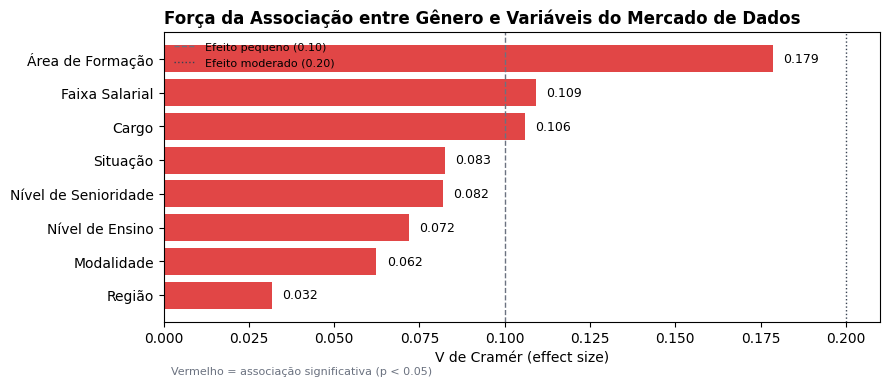

In [26]:
# ── Forest plot do V de Cramér ────────────────────────────────────────────
tab_plot = tab_chi2.sort_values('V de Cramér', ascending=True)
cores_bar = ['#DC2626' if s == 'Sim' else '#9CA3AF' for s in tab_plot['Significativo']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(tab_plot.index, tab_plot['V de Cramér'], color=cores_bar, alpha=0.85)
ax.axvline(0.10, color='#6B7280', linewidth=1, linestyle='--', label='Efeito pequeno (0.10)')
ax.axvline(0.20, color='#374151', linewidth=1, linestyle=':', label='Efeito moderado (0.20)')
for bar, val in zip(bars, tab_plot['V de Cramér']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('V de Cramér (effect size)')
ax.set_title('Força da Associação entre Gênero e Variáveis do Mercado de Dados',
             fontsize=12, fontweight='bold', loc='left')
ax.annotate('Vermelho = associação significativa (p < 0.05)', xy=(0.01, -0.18),
            xycoords='axes fraction', fontsize=8, color='#6B7280')
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig('figures/cramer_v.png', bbox_inches='tight', dpi=150)
plt.show()


### 4.3 Teste Mann-Whitney U — Desigualdade Salarial

Teste **não-paramétrico** — adequado para faixa salarial ordinal e amostras desbalanceadas.  
Executado para o Brasil geral, por ano e por região.

**H₀:** A distribuição salarial de mulheres e homens é idêntica.  
**H₁:** Homens tendem a receber salários maiores que mulheres (`alternative='greater'`).

**Effect size:** r = Z / √N (Cohen, 1992). Interpretação: r ≥ 0.1 = pequeno, ≥ 0.3 = médio, ≥ 0.5 = grande.


In [27]:
def mann_whitney_salarial(df_sub, label='Geral'):
    """Executa Mann-Whitney U e retorna resultados como dict."""
    sub  = df_sub.dropna(subset=['faixa_salarial_num', 'genero'])
    masc = sub[sub['genero'] == 'Masculino']['faixa_salarial_num']
    fem  = sub[sub['genero'] == 'Feminino']['faixa_salarial_num']
    if len(masc) == 0 or len(fem) == 0:
        return None

    U, p = mannwhitneyu(masc, fem, alternative='greater')
    n    = len(masc) + len(fem)
    z    = stats.norm.ppf(1 - p)
    r    = abs(z) / np.sqrt(n)

    return {
        'Grupo':              label,
        'N Masculino':        len(masc),
        'N Feminino':         len(fem),
        'Mediana Masc (rank)': round(masc.median(), 1),
        'Mediana Fem (rank)':  round(fem.median(), 1),
        'Faixa modal Masc':   FAIXA_SALARIAL_ORDEM[int(masc.mode()[0])],
        'Faixa modal Fem':    FAIXA_SALARIAL_ORDEM[int(fem.mode()[0])],
        'U':                  round(U),
        'p-valor':            round(p, 6),
        'Significativo':      'Sim' if p < ALPHA else 'Não',
        'r (effect size)':    round(r, 4),
        'Magnitude r':        ('Grande' if r >= .5 else 'Médio' if r >= .3 else
                                'Pequeno' if r >= .1 else 'Negligenciável'),
    }

res_mw = [mann_whitney_salarial(df, 'Brasil — Geral')]
for ano in ANOS:
    res_mw.append(mann_whitney_salarial(df[df['ano_pesquisa'] == ano], f'Brasil — {ano}'))
for reg in sorted(df['regiao'].dropna().unique()):
    res_mw.append(mann_whitney_salarial(df[df['regiao'] == reg], f'Região: {reg}'))

tab_mw = pd.DataFrame([r for r in res_mw if r]).set_index('Grupo')
print('=== Mann-Whitney U: Diferença Salarial por Gênero ===')
print(tab_mw.to_string())


=== Mann-Whitney U: Diferença Salarial por Gênero ===
                      N Masculino  N Feminino  Mediana Masc (rank)  Mediana Fem (rank) Faixa modal Masc Faixa modal Fem         U   p-valor Significativo  r (effect size)     Magnitude r
Grupo                                                                                                                                                                                     
Brasil — Geral              11900        3538                  5.0                 4.0         R$8k-12k        R$8k-12k  23712840  0.000000           Sim              inf          Grande
Brasil — 2021                1892         430                  4.0                 4.0         R$8k-12k        R$8k-12k    454266  0.000065           Sim           0.0794  Negligenciável
Brasil — 2022                2749         876                  5.0                 4.0         R$8k-12k        R$8k-12k   1349824  0.000000           Sim           0.0906  Negligenciável
Brasil — 20

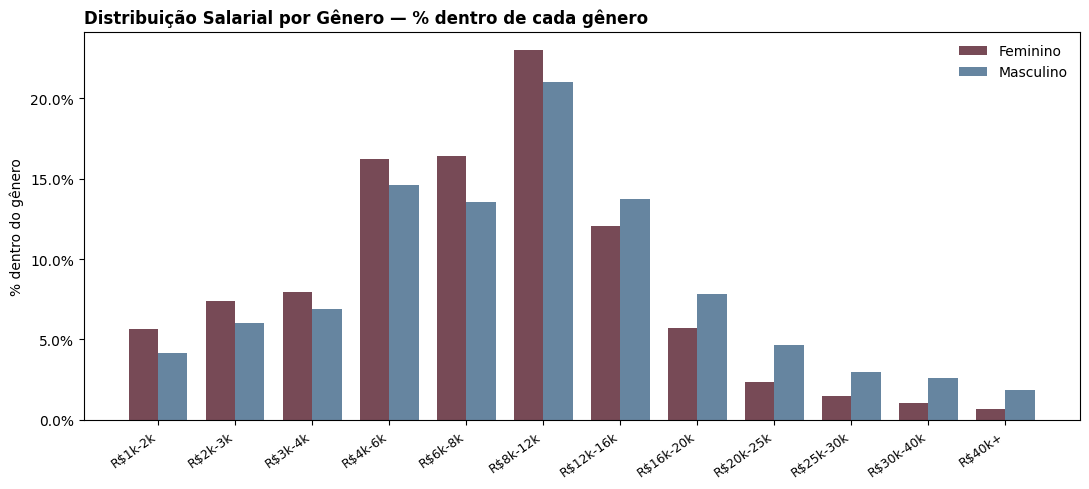

In [28]:
# ── Distribuição salarial por gênero (% dentro do gênero) ────────────────
sub_sal = df.dropna(subset=['faixa_salarial'])
sal_pct = (
    sub_sal.groupby(['faixa_salarial', 'genero'], observed=True)
    .size().unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100)
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(FAIXA_SALARIAL_ORDEM))
w = 0.38
for i, genero in enumerate(['Feminino', 'Masculino']):
    vals = sal_pct.reindex(FAIXA_SALARIAL_ORDEM).get(genero, pd.Series([0]*len(x)))
    ax.bar(x + (i - 0.5)*w, vals, w, color=CORES_GENERO[genero], alpha=0.88, label=genero)

ax.set_xticks(x)
ax.set_xticklabels(FAIXA_SALARIAL_ORDEM, rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% dentro do gênero')
ax.set_title('Distribuição Salarial por Gênero — % dentro de cada gênero',
             fontsize=12, fontweight='bold', loc='left')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/salario_genero.png', bbox_inches='tight', dpi=150)
plt.show()


### 4.4 Regressão Logística Simples — Tendência Temporal

**Pergunta:** A proporção de mulheres no mercado de dados mudou significativamente de 2021 a 2024?

**Modelo:** P(Feminino) = logit⁻¹(β₀ + β₁ × ano_centro)

- **β₁ > 0** → proporção feminina crescendo; **β₁ < 0** → decrescendo
- **OR > 1** → a cada ano adicional, a chance de ser mulher aumenta pelo fator OR
- `ano_centro` = ano − 2021 (0, 1, 2, 3) — centralizar melhora a estabilidade numérica


In [29]:
def regressao_temporal(df_sub, label='Brasil'):
    """Regressão logística simples: gênero ~ ano_centro."""
    sub = df_sub.dropna(subset=['genero_bin', 'ano_centro'])
    if len(sub) < 50:
        return None
    X   = sm.add_constant(sub['ano_centro'])
    mod = sm.Logit(sub['genero_bin'], X).fit(disp=False)
    coef = mod.params['ano_centro']
    p    = mod.pvalues['ano_centro']
    OR   = np.exp(coef)
    ci   = mod.conf_int().loc['ano_centro']
    return {
        'Grupo':               label,
        'β (log-odds/ano)':    round(coef, 4),
        'OR':                  round(OR, 4),
        'IC 95% OR':           f'[{np.exp(ci[0]):.3f}, {np.exp(ci[1]):.3f}]',
        'p-valor':             round(p, 6),
        'Significativo':       'Sim' if p < ALPHA else 'Não',
        'Tendência':           ('Crescente' if coef > 0 and p < ALPHA else
                                'Decrescente' if coef < 0 and p < ALPHA else 'Estável'),
    }

res_temp = [regressao_temporal(df, 'Brasil — Geral')]
for reg in sorted(df['regiao'].dropna().unique()):
    res_temp.append(regressao_temporal(df[df['regiao'] == reg], f'Região: {reg}'))

tab_temp = pd.DataFrame([r for r in res_temp if r]).set_index('Grupo')
print('=== Tendência Temporal da Representatividade Feminina ===')
print(tab_temp.to_string())


=== Tendência Temporal da Representatividade Feminina ===
                      β (log-odds/ano)      OR       IC 95% OR   p-valor Significativo  Tendência
Grupo                                                                                            
Brasil — Geral                  0.0585  1.0603  [1.025, 1.097]  0.000711           Sim  Crescente
Região: Centro-Oeste            0.1135  1.1202  [0.971, 1.292]  0.119501           Não    Estável
Região: Nordeste                0.0407  1.0415  [0.940, 1.155]  0.439353           Não    Estável
Região: Norte                  -0.0507  0.9505  [0.691, 1.308]  0.755645           Não    Estável
Região: Sudeste                 0.0557  1.0573  [1.013, 1.103]  0.010410           Sim  Crescente
Região: Sul                     0.0722  1.0748  [0.989, 1.169]  0.090758           Não    Estável


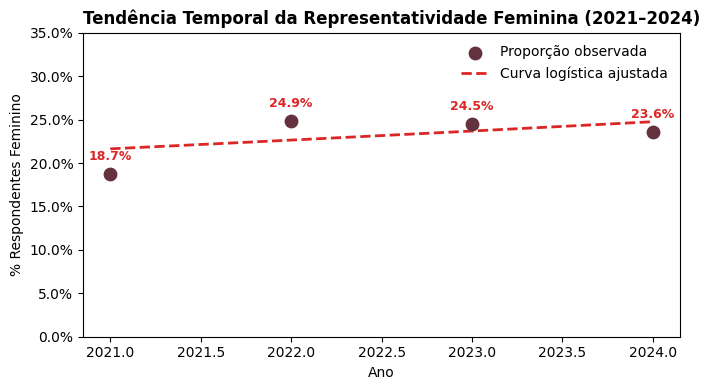

In [30]:
# ── Proporção observada + curva logística ajustada ───────────────────────
pct_obs = df.groupby('ano_num').apply(
    lambda x: (x['genero'] == 'Feminino').mean() * 100
).reset_index(name='pct_fem')

sub_fit = df.dropna(subset=['genero_bin', 'ano_centro'])
X_fit   = sm.add_constant(sub_fit['ano_centro'])
mod_fit = sm.Logit(sub_fit['genero_bin'], X_fit).fit(disp=False)
anos_seq = np.linspace(0, 3, 100)
y_pred   = mod_fit.predict(sm.add_constant(anos_seq)) * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(pct_obs['ano_num'], pct_obs['pct_fem'],
           color=CORES_GENERO['Feminino'], s=80, zorder=5, label='Proporção observada')
ax.plot(anos_seq + 2021, y_pred, color='#DC2626', linewidth=2,
        linestyle='--', label='Curva logística ajustada')
for _, row in pct_obs.iterrows():
    ax.annotate(f"{row['pct_fem']:.1f}%", (row['ano_num'], row['pct_fem']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold', color='#DC2626')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Ano')
ax.set_ylabel('% Respondentes Feminino')
ax.set_title('Tendência Temporal da Representatividade Feminina (2021–2024)',
             fontsize=12, fontweight='bold', loc='left')
ax.legend(frameon=False)
ax.set_ylim(0, 35)
plt.tight_layout()
plt.savefig('figures/tendencia_temporal.png', bbox_inches='tight', dpi=150)
plt.show()


### 4.5 Regressão Logística Múltipla — Preditores Estruturais

**Objetivo:** Identificar quais fatores estruturais predizem ser mulher, controlando simultaneamente  
por cargo, nível, faixa salarial, região e ano.

**Interpretação dos OR:**
- OR < 1 → preditor associado a **menor** probabilidade de ser mulher
- OR > 1 → preditor associado a **maior** probabilidade de ser mulher

> **Nota metodológica:** A regressão usa `drop_first=True` para evitar multicolinearidade  
> (problema da variável perfeitamente colinear com as dummies). A categoria de referência de cada  
> variável é a primeira categoria na ordem alfabética.


In [31]:
cols_modelo = ['genero_bin', 'faixa_salarial_num', 'nivel', 'cargo', 'regiao', 'ano_centro']
df_modelo   = df[cols_modelo].dropna().copy()

df_dummies = pd.get_dummies(df_modelo, columns=['nivel', 'cargo', 'regiao'], drop_first=True)
bool_cols  = df_dummies.select_dtypes(include='bool').columns
df_dummies[bool_cols] = df_dummies[bool_cols].astype(int)

y = df_dummies['genero_bin']
X = sm.add_constant(df_dummies.drop(columns=['genero_bin']))

modelo_mult = sm.Logit(y, X).fit(disp=False, maxiter=200)
print(modelo_mult.summary())


LinAlgError: Singular matrix

In [ ]:
# ── Tabela de Odds Ratios ─────────────────────────────────────────────────
params = modelo_mult.params
conf   = modelo_mult.conf_int()
pvals  = modelo_mult.pvalues

tab_or = pd.DataFrame({
    'OR':         np.exp(params),
    'IC 95% inf': np.exp(conf[0]),
    'IC 95% sup': np.exp(conf[1]),
    'p-valor':    pvals,
    'Sig.':       pvals.apply(lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))),
}).drop(index='const').round(4)

print(f'N = {len(y):,} | Pseudo-R² (McFadden) = {modelo_mult.prsquared:.4f}')
print(f'AIC = {modelo_mult.aic:.1f} | Log-likelihood = {modelo_mult.llf:.1f}')
print()
print(tab_or.to_string())


In [ ]:
# ── Forest plot dos Odds Ratios significativos ───────────────────────────
sig  = tab_or[tab_or['p-valor'] < ALPHA].sort_values('OR')
y_pos = np.arange(len(sig))
cores = ['#DC2626' if v < 1 else '#2563EB' for v in sig['OR']]

fig, ax = plt.subplots(figsize=(9, max(4, len(sig) * 0.45)))
ax.scatter(sig['OR'], y_pos, color=cores, s=60, zorder=5)
for i, (_, row) in enumerate(sig.iterrows()):
    ax.plot([row['IC 95% inf'], row['IC 95% sup']], [i, i], color=cores[i], linewidth=1.5, alpha=0.7)
ax.axvline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.5, label='OR = 1 (sem efeito)')
ax.set_yticks(y_pos)
ax.set_yticklabels(sig.index, fontsize=8)
ax.set_xlabel('Odds Ratio (IC 95%)')
ax.set_title('Forest Plot — Preditores da Probabilidade de Ser Mulher (p < 0.05)',
             fontsize=11, fontweight='bold', loc='left')
ax.annotate('← menor prob. feminina | maior prob. feminina →',
            xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=8, color='#6B7280')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig('figures/forest_plot.png', bbox_inches='tight', dpi=150)
plt.show()


### 4.6 Síntese dos Resultados Estatísticos


In [ ]:
print('=' * 70)
print('SÍNTESE DOS RESULTADOS ESTATÍSTICOS')
print('=' * 70)

print('\n[1] ASSOCIAÇÃO GÊNERO × VARIÁVEIS (Qui-quadrado + V de Cramér)')
print('-' * 60)
for label, row in tab_chi2.sort_values('V de Cramér', ascending=False).iterrows():
    sig = '✓' if row['Significativo'] == 'Sim' else '✗'
    print(f"  {sig} {label:<30} V={row['V de Cramér']:.3f} ({row['Magnitude']}) | p={row['p-valor']:.4f}")

print('\n[2] DESIGUALDADE SALARIAL — Brasil Geral (Mann-Whitney U)')
print('-' * 60)
r_mw = tab_mw.loc['Brasil — Geral']
print(f"  U={r_mw['U']:.0f} | p={r_mw['p-valor']:.6f} | r={r_mw['r (effect size)']:.3f} ({r_mw['Magnitude r']})")
print(f"  Faixa modal Masculino: {r_mw['Faixa modal Masc']} | Faixa modal Feminino: {r_mw['Faixa modal Fem']}")

print('\n[3] TENDÊNCIA TEMPORAL (Regressão Logística Simples)')
print('-' * 60)
r_t = tab_temp.loc['Brasil — Geral']
print(f"  β={r_t['β (log-odds/ano)']:.4f} | OR={r_t['OR']:.4f} | IC95%={r_t['IC 95% OR']} | p={r_t['p-valor']:.4f}")
print(f"  Tendência: {r_t['Tendência']}")

print('\n[4] PREDITORES ESTRUTURAIS (Regressão Logística Múltipla)')
print('-' * 60)
print(f"  N={len(y):,} | Pseudo-R²={modelo_mult.prsquared:.4f} | AIC={modelo_mult.aic:.1f}")
sig_preds = tab_or[tab_or['p-valor'] < ALPHA].sort_values('OR')
print(f"  Preditores significativos: {len(sig_preds)}/{len(tab_or)}")
print('  Top 5 que reduzem a chance de ser mulher (OR < 1):')
for nome, row in sig_preds[sig_preds['OR'] < 1].head(5).iterrows():
    print(f"    {nome:<40} OR={row['OR']:.3f} | p={row['p-valor']:.4f}")
print('  Top 5 que aumentam a chance de ser mulher (OR > 1):')
for nome, row in sig_preds[sig_preds['OR'] > 1].tail(5).iterrows():
    print(f"    {nome:<40} OR={row['OR']:.3f} | p={row['p-valor']:.4f}")

# Exporta tabelas
with pd.ExcelWriter('resultados_estatisticos.xlsx') as writer:
    tab_chi2.to_excel(writer, sheet_name='Qui-quadrado e Cramer V')
    tab_mw.to_excel(writer, sheet_name='Mann-Whitney Salarial')
    tab_temp.to_excel(writer, sheet_name='Tendência Temporal')
    tab_or.to_excel(writer, sheet_name='Regressão Logística Múltipla')
print('\n✅ Tabelas exportadas: resultados_estatisticos.xlsx')


---
## Seção 5 — Modelagem Preditiva (Machine Learning)

### Estratégia geral

| Aspecto | Decisão |
|---------|---------|
| Treino | Anos 2021, 2022, 2023 |
| Predição | Ano 2024 (fora da amostra temporal) |
| Targets | Faixa Salarial · Nível de Senioridade · Gestor/a |
| Tipo de problema | Classificação multiclasse (Faixa e Nível) / binária (Gestor) |
| Modelos comparados | Regressão Logística · Random Forest · XGBoost |
| Seleção | Melhor F1-macro em CV 5-fold estratificado |
| Análise de equidade | Desempenho separado por gênero (fairness) |

> **Modelo A:** treino 2021–2023, predição 2024 — sem features de IA  
> **Modelo B:** treino e teste em 2024 (70/30) — com features de IA generativa

### 5.1 Funções de feature engineering e pipeline


In [ ]:
# ── Variáveis-preditoras base (disponíveis em todos os anos) ─────────────
# nivel_ensino é tratada como numérica (ordinal encoding antes do pipeline sklearn)
BASE_FEATURES = [
    'nivel_ensino',     # ordinal → int
    'area_formacao',    # nominal
    'cargo',            # nominal
    'tempo_area_dados', # nominal (faixas de tempo)
    'tempo_area_ti',    # nominal (faixas de tempo)
    'modalidade',       # nominal
    'setor',            # nominal
    'regiao',           # nominal
    'situacao',         # nominal
]

# Targets e seus tipos de problema
TARGETS = {
    'faixa_salarial': 'multiclass',
    'nivel':          'multiclass',
    'gestor':         'binario',
}
TARGET_LABELS = {
    'faixa_salarial': 'Faixa Salarial',
    'nivel':          'Senioridade',
    'gestor':         'Gestor/a',
}

def encode_ordinal(series: pd.Series, ordem: list) -> pd.Series:
    """
    Converte variável ordinal em int seguindo a ordem fornecida.
    Categorias não mapeadas → NaN (não são silenciosamente imputadas).
    """
    cat   = pd.Categorical(series, categories=ordem, ordered=True)
    codes = cat.codes.astype(float)
    codes[codes == -1] = np.nan
    return codes

def prepare_xy(df: pd.DataFrame, target: str, extra_features: list = None) -> tuple:
    """
    Prepara X, y e metadados para um dado target.
    - nivel_ensino é codificada como ordinal antes do pipeline.
    - Demais features categóricas ficam como string para OHE no ColumnTransformer.
    - Retorna (X, y, meta) onde meta contém genero e ano_pesquisa para análise de equidade.
    """
    feats = BASE_FEATURES.copy()
    if extra_features:
        feats += [f for f in extra_features if f in df.columns]

    sub = df[feats + [target, 'ano_pesquisa', 'genero']].copy()
    sub['nivel_ensino'] = encode_ordinal(sub['nivel_ensino'], NIVEL_ENSINO_ORDEM)

    if target == 'faixa_salarial':
        sub['y'] = encode_ordinal(sub['faixa_salarial'], FAIXA_SALARIAL_ORDEM)
    elif target == 'nivel':
        sub['y'] = encode_ordinal(sub['nivel'], NIVEL_SENIORIDADE_ORDEM)
    elif target == 'gestor':
        sub['y'] = (sub['gestor'] == 1.0).astype(float)

    sub = sub.dropna(subset=['y'])
    sub['y'] = sub['y'].astype(int)

    X    = sub[feats].copy()
    y    = sub['y']
    meta = sub[['genero', 'ano_pesquisa']].copy()
    return X, y, meta

print('✅ Feature engineering definido')


In [ ]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """
    Constrói ColumnTransformer automático com base nos dtypes de X:
    - Numéricas  → SimpleImputer(mediana) + StandardScaler
    - Categóricas → SimpleImputer(moda) + OneHotEncoder(handle_unknown='ignore')
    """
    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    transformers = []
    if num_cols:
        transformers.append(('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scl', StandardScaler()),
        ]), num_cols))
    if cat_cols:
        transformers.append(('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cat_cols))
    return ColumnTransformer(transformers, remainder='drop')


def get_models(task_type: str) -> dict:
    """
    Retorna os 3 modelos configurados para o tipo de problema.
    - class_weight='balanced' na LR e RF para compensar o desbalanceamento de classes.
    - scale_pos_weight no XGBoost para o caso binário.
    """
    if task_type == 'binario':
        return {
            'Regressão Logística': LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'),
            'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
            'XGBoost':             XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='logloss', scale_pos_weight=5, verbosity=0),
        }
    else:
        return {
            'Regressão Logística': LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'),
            'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
            'XGBoost':             XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='mlogloss', verbosity=0),
        }


def run_cv(X: pd.DataFrame, y: pd.Series, models: dict, cv: int = 5) -> pd.DataFrame:
    """
    Cross-validation estratificado (StratifiedKFold).
    Métrica: F1-macro — penaliza igualmente erros em todas as classes, incluindo as minoritárias.
    Retorna DataFrame com mean e std do F1-macro por modelo.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    results = []
    for name, model in models.items():
        pipe   = Pipeline([('pre', build_preprocessor(X)), ('clf', model)])
        scores = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
        results.append({'Modelo': name, 'F1_macro_mean': scores.mean(), 'F1_macro_std': scores.std()})
        print(f'    {name:25s}: {scores.mean():.3f} ± {scores.std():.3f}')
    return pd.DataFrame(results)


print('✅ Pipeline de modelos definido')


In [ ]:
def treinar_avaliar(target: str, task_type: str,
                    df_train: pd.DataFrame, df_test: pd.DataFrame,
                    extra_features: list = None, label_extra: str = '') -> dict:
    """
    Executa o ciclo completo de treino e avaliação:
    1. Prepara X_train, y_train, X_test, y_test
    2. Cross-validation no treino → seleciona melhor modelo por F1-macro
    3. Retreina no treino completo
    4. Avalia no teste (relatório de classificação)
    5. Quebra o desempenho por gênero (análise de equidade / fairness)
    Retorna dict com pipeline, predições e metadados para SHAP.
    """
    tag = f'{TARGET_LABELS[target]}{" " + label_extra if label_extra else ""}'
    print(f'\n{"="*60}')
    print(f'  {tag}')
    print(f'{"="*60}')

    X_train, y_train, _         = prepare_xy(df_train, target, extra_features)
    X_test,  y_test,  meta_test = prepare_xy(df_test,  target, extra_features)
    print(f'  Treino: {len(X_train):,} | Teste: {len(X_test):,} | Classes: {sorted(y_train.unique())}')

    print(f'\n  [Cross-Validation {5}-fold — F1-macro]')
    models   = get_models(task_type)
    cv_df    = run_cv(X_train, y_train, models)
    best_name = cv_df.loc[cv_df['F1_macro_mean'].idxmax(), 'Modelo']
    print(f'\n  Melhor modelo: {best_name}')

    pipe = Pipeline([('pre', build_preprocessor(X_train)), ('clf', models[best_name])])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f'\n  [Relatório de Classificação — Teste]')
    print(classification_report(y_test, y_pred, zero_division=0))

    # ── Análise de equidade por gênero ──────────────────────────────────────
    print(f'  [Desempenho por Gênero — fairness check]')
    gender_rows = []
    for g in ['Masculino', 'Feminino']:
        mask = meta_test['genero'] == g
        if mask.sum() == 0:
            continue
        gender_rows.append({
            'Gênero':   g, 'N': int(mask.sum()),
            'Acurácia': round(accuracy_score(y_test[mask], y_pred[mask]), 4),
            'F1_macro': round(f1_score(y_test[mask], y_pred[mask], average='macro', zero_division=0), 4),
        })
    print(pd.DataFrame(gender_rows).to_string(index=False))

    return {
        'target': target, 'label': tag, 'best_name': best_name, 'pipe': pipe,
        'cv_df': cv_df, 'X_train': X_train, 'X_test': X_test,
        'y_test': y_test, 'y_pred': y_pred, 'gender_rows': gender_rows, 'meta_test': meta_test,
    }

print('✅ Função de treino e avaliação definida')


### 5.2 Carregamento dos dados e verificação das features de IA


In [ ]:
df_train = pd.read_parquet('data/df_train.parquet')
df_test  = pd.read_parquet('data/df_test.parquet')

print(f'df_train: {len(df_train):,} linhas — anos {sorted(df_train["ano_pesquisa"].unique())}')
print(f'df_test:  {len(df_test):,}  linhas — anos {sorted(df_test["ano_pesquisa"].unique())}')

# Verifica quais features de IA estão disponíveis e preenchidas no teste
ia_disponivel = [
    c for c in IA_FEATS_ALL
    if c in df_test.columns and df_test[c].notna().sum() > 0
]
print(f'\nFeatures de IA disponíveis e não-vazias no df_test: {len(ia_disponivel)}/{len(IA_FEATS_ALL)}')


### 5.3 Modelo A — Treino 2021–2023 / Predição 2024 (sem IA)

Objetivo: verificar se os padrões do mercado de dados aprendidos em 2021–2023  
ainda generalizam para 2024, e se há disparidade de desempenho entre gêneros.


In [ ]:
results_A = {}
for target, task_type in TARGETS.items():
    results_A[target] = treinar_avaliar(
        target, task_type, df_train, df_test,
        extra_features=None,
        label_extra='[Modelo A — sem IA]',
    )


### 5.4 Modelo B — Treino e Teste em 2024 (base + IA generativa)

Objetivo: avaliar o impacto das features de IA na predição,  
usando um split 70/30 estratificado por target e gênero dentro de 2024.


In [ ]:
results_B = {}

for target, task_type in TARGETS.items():
    print(f'\n{"-"*60}')
    print(f'  {TARGET_LABELS[target]} — [Modelo B — base + IA] (2024 only)')
    print(f'{"-"*60}')

    X_all, y_all, meta_all = prepare_xy(df_test, target, extra_features=ia_disponivel)

    # Stratify por target E gênero simultaneamente — preserva proporção em ambas as dimensões
    strat = y_all.astype(str) + '_' + meta_all['genero']

    X_tr, X_te, y_tr, y_te, meta_tr, meta_te = train_test_split(
        X_all, y_all, meta_all, test_size=0.30, random_state=SEED, stratify=strat
    )
    print(f'  Treino 2024: {len(X_tr):,} | Teste 2024: {len(X_te):,}')

    models   = get_models(task_type)
    cv_df    = run_cv(X_tr, y_tr, models)
    best_name = cv_df.loc[cv_df['F1_macro_mean'].idxmax(), 'Modelo']
    print(f'\n  Melhor modelo: {best_name}')

    pipe = Pipeline([('pre', build_preprocessor(X_tr)), ('clf', models[best_name])])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)

    print(f'\n  [Relatório de Classificação — Teste 2024 (30%)]')
    print(classification_report(y_te, y_pred, zero_division=0))

    gender_rows = []
    for g in ['Masculino', 'Feminino']:
        mask = meta_te['genero'] == g
        if mask.sum() == 0:
            continue
        gender_rows.append({
            'Gênero': g, 'N': int(mask.sum()),
            'Acurácia': round(accuracy_score(y_te[mask], y_pred[mask]), 4),
            'F1_macro': round(f1_score(y_te[mask], y_pred[mask], average='macro', zero_division=0), 4),
        })
    print(f'\n  [Desempenho por Gênero]')
    print(pd.DataFrame(gender_rows).to_string(index=False))

    results_B[target] = {
        'target': target, 'label': f'{TARGET_LABELS[target]} [B+IA]',
        'best_name': best_name, 'pipe': pipe, 'cv_df': cv_df,
        'X_train': X_tr, 'X_test': X_te, 'y_test': y_te, 'y_pred': y_pred,
        'gender_rows': gender_rows, 'meta_test': meta_te,
    }


---
## Seção 6 — Explicabilidade com SHAP

### O que é SHAP?

SHAP (SHapley Additive exPlanations) atribui a cada feature uma contribuição para a predição,  
baseada na teoria dos jogos cooperativos (valores de Shapley).  
Permite entender **quais variáveis mais influenciam** a predição do modelo e **em qual direção**.

### Estratégia:
- Para modelos de árvore (Random Forest / XGBoost): `TreeExplainer` — exato e eficiente
- Para regressão logística: `LinearExplainer`
- Multiclasse: média do |SHAP| entre todas as classes
- Features de IA são destacadas em laranja nos gráficos do Modelo B

### 6.1 Funções de SHAP


In [ ]:
def compute_shap(pipe: Pipeline, X: pd.DataFrame,
                  model_name: str, max_samples: int = 600) -> tuple:
    """
    Extrai SHAP values para um pipeline sklearn.
    - Usa amostragem (max_samples) para eficiência computacional.
    - Retorna: (mean_abs_shap por feature, array de nomes de features).
    """
    pre = pipe.named_steps['pre']
    clf = pipe.named_steps['clf']
    X_t = pre.transform(X)

    try:
        feat_names = np.array(pre.get_feature_names_out())
    except Exception:
        feat_names = np.array([f'f{i}' for i in range(X_t.shape[1])])

    n   = min(max_samples, X_t.shape[0])
    idx = np.random.RandomState(SEED).choice(X_t.shape[0], n, replace=False)
    X_s = X_t[idx]

    if 'XGBoost' in model_name or 'Random Forest' in model_name:
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(X_s)
    else:
        explainer = shap.LinearExplainer(clf, X_s, feature_dependence='independent')
        sv = explainer.shap_values(X_s)

    # Multiclasse: sv é uma lista de arrays (1 por classe) → média do |SHAP|
    if isinstance(sv, list):
        mean_abs = np.mean([np.abs(s) for s in sv], axis=0)
    else:
        mean_abs = np.abs(sv)

    return mean_abs.mean(axis=0), feat_names


def plot_shap_bar(mean_shap: np.ndarray, feat_names: np.ndarray,
                  top_n: int = 15, title: str = 'SHAP',
                  fname: str = 'shap.png', highlight_ia: bool = False):
    """
    Barplot horizontal dos top-N features por |SHAP| médio.
    - highlight_ia=True: features de IA são pintadas em laranja (#F4A43B)
      para destacar sua contribuição incremental no Modelo B.
    """
    top_idx = np.argsort(mean_shap)[::-1][:top_n]
    names   = feat_names[top_idx]
    vals    = mean_shap[top_idx]

    # Remove prefixos internos do ColumnTransformer (cat__, num__)
    clean = lambda n: n.replace('cat__', '').replace('num__', '').replace('_cod', '')
    names_clean = [clean(n) for n in names]

    if highlight_ia:
        colors = ['#F4A43B' if 'ia_' in n else '#4C8FBF' for n in names_clean]
    else:
        colors = ['#4C8FBF'] * len(names_clean)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(names_clean[::-1], vals[::-1], color=colors[::-1])
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(title, fontweight='bold', loc='left')

    if highlight_ia:
        ax.legend(handles=[
            mpatches.Patch(color='#F4A43B', label='Feature de IA generativa'),
            mpatches.Patch(color='#4C8FBF', label='Feature base'),
        ], loc='lower right', frameon=False)

    plt.tight_layout()
    plt.savefig(f'figures/{fname}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  💾 figures/{fname}')

print('✅ Funções SHAP definidas')


### 6.2 SHAP por target — Modelo A e Modelo B


In [ ]:
shap_cache = {}

for target in TARGETS:
    label = TARGET_LABELS[target]
    safe  = target.replace(' ', '_')

    # ── Modelo A ──────────────────────────────────────────────────────────
    try:
        r = results_A[target]
        ms, fn = compute_shap(r['pipe'], r['X_test'], r['best_name'])
        shap_cache[f'A_{target}'] = (ms, fn)
        plot_shap_bar(ms, fn,
                      title=f'SHAP — {label} · Modelo A ({r["best_name"]})',
                      fname=f'shap_A_{safe}.png')
    except Exception as e:
        print(f'⚠️ SHAP Modelo A / {label}: {e}')

    # ── Modelo B (com features de IA) ─────────────────────────────────────
    try:
        r = results_B[target]
        ms, fn = compute_shap(r['pipe'], r['X_test'], r['best_name'])
        shap_cache[f'B_{target}'] = (ms, fn)
        plot_shap_bar(ms, fn,
                      title=f'SHAP — {label} · Modelo B + IA ({r["best_name"]})',
                      fname=f'shap_B_{safe}.png',
                      highlight_ia=True)
    except Exception as e:
        print(f'⚠️ SHAP Modelo B / {label}: {e}')


### 6.3 Comparação SHAP: Modelo A vs Modelo B

Compara as top features dos dois modelos lado a lado para cada target,  
mostrando o que a adição das features de IA muda na explicação do modelo.


In [ ]:
def plot_shap_comparacao(target: str, top_n: int = 12):
    """
    Plota lado a lado o SHAP do Modelo A (sem IA) e Modelo B (com IA)
    para o mesmo target. Útil para identificar quais features de IA
    entraram no top-N e quais features base foram deslocadas.
    """
    key_a = f'A_{target}'
    key_b = f'B_{target}'
    if key_a not in shap_cache or key_b not in shap_cache:
        print(f'⚠️ SHAP não disponível para {target}')
        return

    ms_a, fn_a = shap_cache[key_a]
    ms_b, fn_b = shap_cache[key_b]

    clean = lambda n: n.replace('cat__', '').replace('num__', '')

    def top(ms, fn, n):
        idx = np.argsort(ms)[::-1][:n]
        return [clean(fn[i]) for i in idx], ms[idx]

    names_a, vals_a = top(ms_a, fn_a, top_n)
    names_b, vals_b = top(ms_b, fn_b, top_n)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, names, vals, subtitle, hl in [
        (axes[0], names_a, vals_a, 'Modelo A (sem IA)', False),
        (axes[1], names_b, vals_b, 'Modelo B (com IA)', True),
    ]:
        colors = ['#F4A43B' if 'ia_' in n else '#4C8FBF' for n in names] if hl else ['#4C8FBF']*len(names)
        ax.barh(names[::-1], vals[::-1], color=colors[::-1])
        ax.set_xlabel('Mean |SHAP value|')
        ax.set_title(subtitle, fontweight='bold')

    fig.suptitle(f'SHAP Comparativo — {TARGET_LABELS[target]}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'figures/shap_comp_{target}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  💾 {fname}')


for target in TARGETS:
    plot_shap_comparacao(target)


---
## Observações Finais

### Limitações

- O State of Data é uma pesquisa por conveniência (não probabilística): os resultados descrevem  
  os respondentes, não necessariamente todo o mercado brasileiro.
- Respondentes de gênero não-binário foram excluídos para viabilizar a comparação binária;  
  uma análise inclusiva desse grupo é relevante como trabalho futuro.
- O dataset de 2024 inclui features de IA ausentes nos anos anteriores, criando  
  descontinuidade estrutural que pode afetar os modelos longitudinais (Modelo A).
- O SHAP foi calculado com amostragem (`max_samples=600`) para viabilidade computacional;  
  aumentar esse valor pode refinar os resultados em máquinas com mais memória.

### Próximos passos sugeridos

1. **Ampliar a análise de equidade**: calcular métricas de fairness formais (demographic parity,  
   equalized odds) para verificar se o modelo prejudica sistematicamente um grupo.
2. **Ajuste de hiperparâmetros**: usar `GridSearchCV` ou `Optuna` para refinar os modelos,  
   especialmente o XGBoost que tem mais hiperparâmetros sensíveis.
3. **Análise de interação no SHAP**: usar `shap.Interaction` para capturar efeitos combinados  
   de gênero × cargo × região.
4. **Inclusão de outras variáveis**: ferramentas usadas, linguagens de programação, tamanho da empresa.
